<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week3_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Hanif Faishal Hilmi

NIM   : 2341720116

Kelas : TI-3F

# Praktikum D1

Memberikan akses ke google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Melakukan transformasi linier brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-4112814772.py:19: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


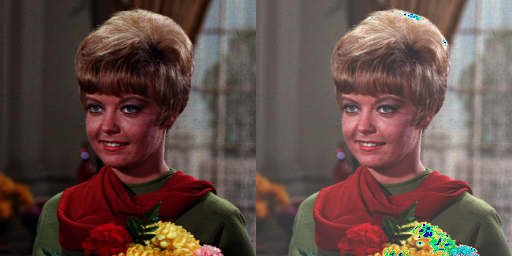

In [4]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv2.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# Tugas Praktikum D1

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang
terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:
*Gunakan Gambar KTM

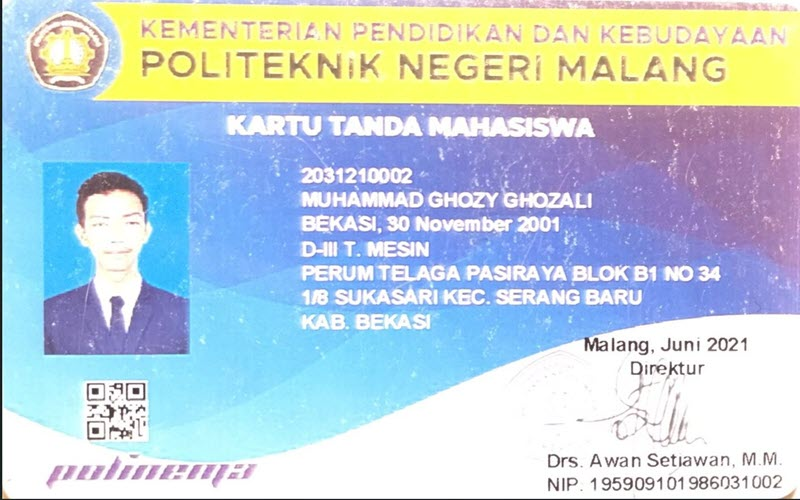

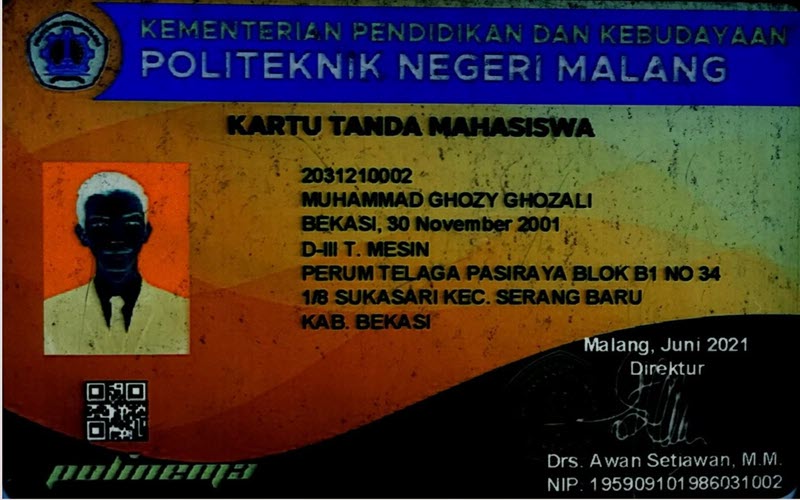

In [5]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')

# melakukan inverse
ktm_inverse = 255 - ktm

# menampilkan hasil
cv2_imshow(ktm)
cv2_imshow(ktm_inverse)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

 Mengubah tingkat kecerahan citra dan contrast
----------------------------------
Masukkan nilai kecerahan [-255 - 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


/tmp/ipython-input-1391770221.py:20: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


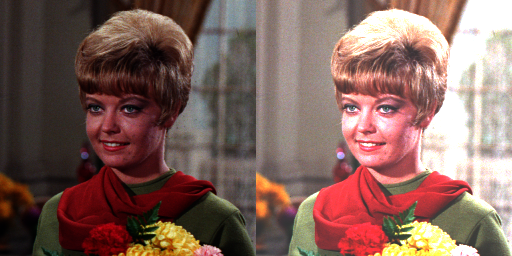

In [6]:

print(' Mengubah tingkat kecerahan citra dan contrast')
print('----------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
  contrast = float(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error, not a number')

original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff')
# Konversi ke float agar aman dihitung
original_float = original.astype(np.float32)

brightness_image = np.zeros(original.shape, original.dtype)
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)
      contrast_image[y,x,c] = np.clip(contrast * (original_float[y,x,c]) + brightness, 0, 255)

final_frame = cv2.hconcat((original, contrast_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:

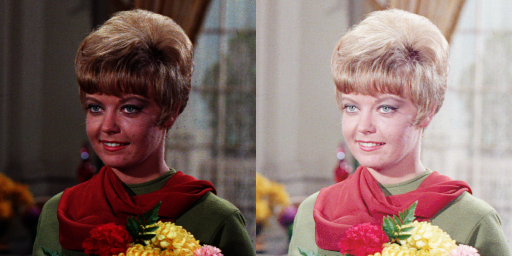

In [7]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

c = 255 / np.log(1 + np.max(original))

log_transform = c * (np.log(original + 1))

log_transform = np.array(log_transform, dtype = np.uint8)

final_frame = cv2.hconcat((original, log_transform))
cv2_imshow(final_frame)


4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:


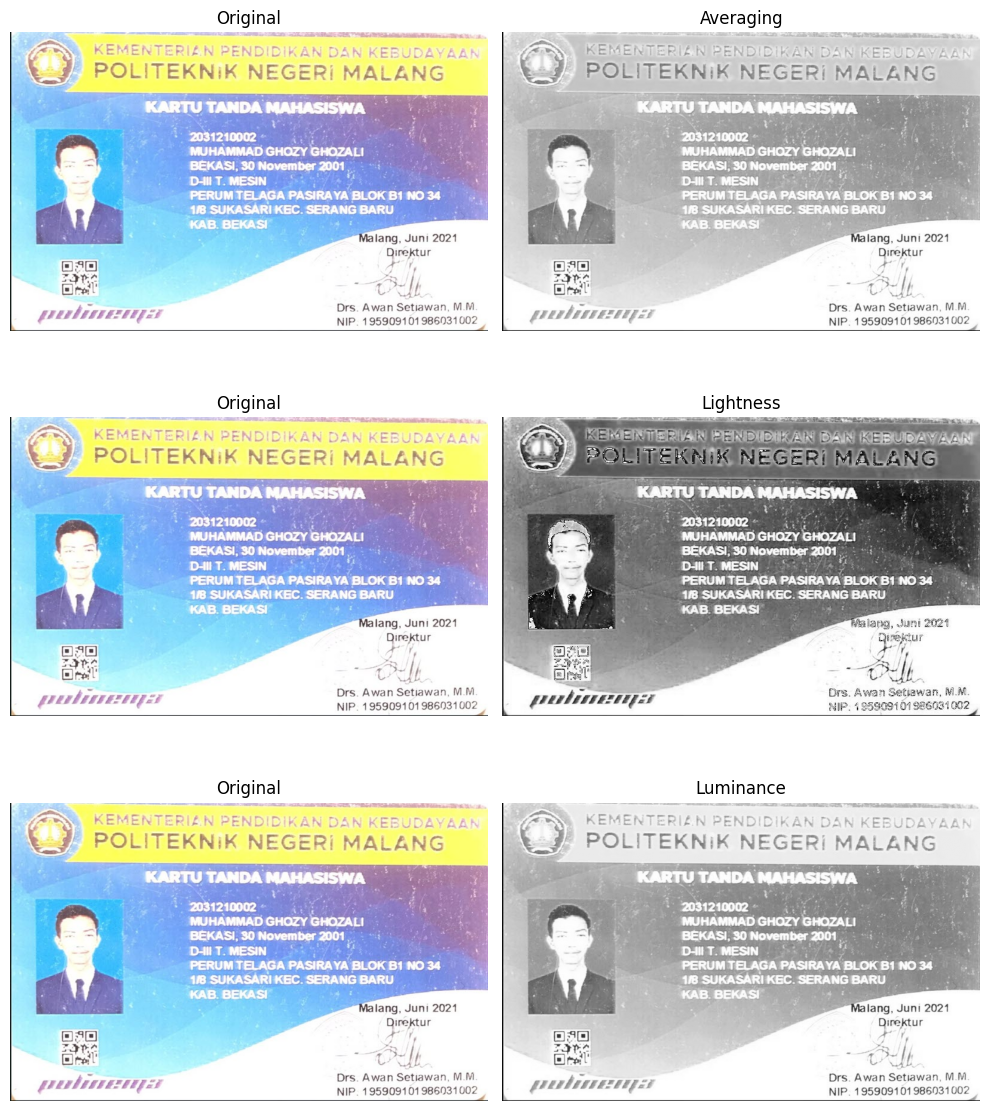

In [8]:
import matplotlib.pyplot as plt

ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')

B, G, R = cv2.split(ktm)
ktm_rgb = cv2.cvtColor(ktm, cv2.COLOR_BGR2RGB)

# Averaging
gray_avg = ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3).astype(np.uint8)

# Lightness
gray_lightness = ((np.maximum(np.maximum(R,G), B)+np.minimum(np.minimum(R,G), B)) / 2).astype(np.uint8)

# Luminance
gray_luminance = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

plt.figure(figsize=(10, 12))

# Original vs Averaging
plt.subplot(3, 2, 1)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")
plt.axis("off")

# Original vs Lightness
plt.subplot(3, 2, 3)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(gray_lightness, cmap='gray')
plt.title("Lightness")
plt.axis("off")

# Original vs Luminance
plt.subplot(3, 2, 5)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(gray_luminance, cmap='gray')
plt.title("Luminance")
plt.axis("off")

plt.tight_layout()
plt.show()

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna
biru menjadi grayscale seperti pada contoh berikut:

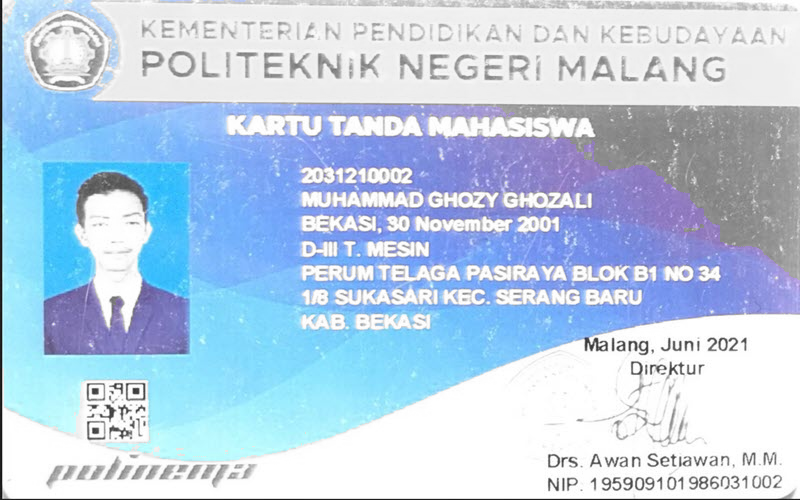

In [15]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')
ktm_rgb = cv2.cvtColor(ktm, cv2.COLOR_BGR2RGB)

# Konversi ke HSV
hsv = cv2.cvtColor(ktm, cv2.COLOR_BGR2HSV)

# Rentang biru HSV
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)
result = cv2.bitwise_and(ktm, ktm, mask=mask)

# Grayscale bagian lain
gray = cv2.cvtColor(ktm, cv2.COLOR_BGR2GRAY)
gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

final = np.where(mask[..., None] != 0, result, gray_bgr)

cv2_imshow(final)